#BIOF2001 Project 1 - 3036498203


##Objective:

Create a classification model for predicting alzheimers disease on subject metadata and gene expression data and apply this model onto new unseen data.

##Dataset Description:

The dataset used for training this model are as following:

1. Metadata - metadata.csv for 400 subjects:
- Demographics:

  - Age: Continuous variable representing the age of the subject.

  - Gender: Categorical variable (Male or Female).

- Laboratory Center: The center where the sample was processed:
  - Center01
  - Center02
  - Center03

- Target Variable: Binary label indicating whether a subject has Alzheimer's disease
  - 1 for Alzheimer's
  - 0 for healthy

2. Gene Expression Data - gene_expression_data.csv for 300 subjects :

- For 300 of the 400 subjects this data is available
- The data consists of 2000 genes measured in log-normalized counts.
- These values represent the relative expression levels of each gene in the sample.

The dataset used for testing and making real predictions on will be released on the competition day. Before the competition, the testing sets have mock placeholder sets.







##Preprocessing

####Inspecting data

The datasets are inspected to confirm amount of data, format of data, duplicate subject_ids, and missing values to help decide which preprocessing steps to take.

In [1]:
#import library
import pandas as pd

In [2]:
#load data
metadata = pd.read_csv("metadata.csv")
gene_expression = pd.read_csv("gene_expression_data.csv")

#check rows & columns
print("Metadata shape:", metadata.shape)
print("Gene expression shape:", gene_expression.shape)

#inspect first rows
print("\nMetadata head:")
print(metadata.head())
print("\nGene expression head:")
print(gene_expression.head())

#check for duplicated values
print("\nDuplicates values in metadata", metadata.duplicated().sum())
print("\nDuplicates values in gene expression data", gene_expression.duplicated().sum())

#check for missing values
print("\nMissing values in metadata:")
print(metadata.isnull().sum().sum())

print("\nMissing values in gene expression:")
print(gene_expression.isnull().sum().sum())

Metadata shape: (400, 5)
Gene expression shape: (300, 2001)

Metadata head:
  Subject_ID  Age  Gender    Center  Label
0  S-9C184CG   39    Male  Center01      0
1  S-BBDE11G   63  Female  Center01      0
2  S-C70838G   61  Female  Center01      0
3  S-3202AEG   46  Female  Center01      0
4  S-8ECF42G   72  Female  Center01      1

Gene expression head:
  Subject_ID    ADORA3    ATP2A3     PSEN1   MORF4L2    PCED1B  FLJ40194  \
0  S-9C184CG  8.158574  4.828645  2.508642  7.843141  5.543410  3.017996   
1  S-BBDE11G  6.426833  6.435132  7.847280  0.486615  1.348097  8.449648   
2  S-C70838G  6.371592  7.418529  4.748030  6.513994  6.340568  7.049241   
3  S-3202AEG  9.137031  4.590351  7.490282  5.457043  4.762770  9.315048   
4  S-8ECF42G  5.778376  2.566962  5.384205  8.390469  3.376243  4.978017   

        NXT2     CEBPD     RIPK4  ...  SLC12A9-AS1  ANKRD36B     AKAP1  \
0   8.546155  4.004920  6.622391  ...     7.103816  2.914266  6.566546   
1   3.610745  6.473317  0.548076  ... 

In [3]:
#check for duplicated values of subject_id
print("Dupliacted values in Subject_ID:")
print(metadata["Subject_ID"].duplicated().sum())
print(gene_expression["Subject_ID"].duplicated().sum())

Dupliacted values in Subject_ID:
0
0


####Explanation and analysis
Shape: This confirms that there is gene expression data for fewer subjects (300) than the number of subjects in the metadata (400), meaning not all subjects have gene expression data. This means the final dataset used for training must only include 300 subjects - the ones that have metadata for them. It also confirms that there is 2001 columns: 2000 gene columns, 1 object column (Subject_ID) - all floating point numbers.

Head: This helped double check column header names and if they exist in both datasets. This will help for merging the two on the correctly named "Subject_id".

Duplicated: Checking duplicates ensures subject_ids only exist once for a single gene sample - since there are none we did not have to remove any but if there were we would have to remove the extra values to prevent bias as this would cause our evaluation later to be better than reality.

Missing values: There are 4539 missing gene expression values. In total we have 300x2000 = 600000 gene values so only 0.76% (4539/6000000 = 0.000757) is actually missing. Since this is such a small percentage we must not drop entire columns, but rather impute these values.


####Distribution of missing values

In [4]:
#check distribution of null values
print(gene_expression.isnull().sum().sort_values(ascending=False).head(10))
print(gene_expression.isnull().sum(axis=1).sort_values(ascending=False).head(10))

MIR890             51
CUL5               51
CHAT               50
TMC3-AS1           50
RPL3               50
ENSG00000285664    50
ANKMY2             50
MIR6845            50
RALY               49
PIK3R3             49
dtype: int64
26     26
169    26
51     25
277    25
199    24
190    24
129    23
203    23
192    22
153    22
dtype: int64


####Explanation and analysis
To decide how to impute later , the distibution of missing values was checked. This showed that there wasnt a single gene that had a large proportion of the missing values itself. Even genes with the most missing values had a small maximum of 50 which seems small compared to the size of the entire dataset so there wasnt a disproportionate effect on certain subjects. This determined average values like median values should be used for imputation.

####Merging datasets

In [5]:
#merge datasets
merged = pd.merge(metadata, gene_expression, on='Subject_ID')

#check shape
print(merged.shape)

(300, 2005)


####Results
Both sets were then merged on the "Subject_ID" column. The merge function only keeps values that exist in both sets so the final merged dataset only contains the 300 subjects that had metadata for them.

####Label distribution analysis

In [6]:
#check amount and distribution of labels
print(merged["Label"].value_counts())

Label
0    180
1    120
Name: count, dtype: int64


####Explanation and analysis

180/300 = 0.6

120/300 = 0.4

Class imbalance is checked for and we can see there is 60% healthy (0) and 40% alzheimers (1). This is weakly imbalanced and does not show strong imbalance. This means the minority class should be common enough for a model not to have extreme bias in it.

Since there is existing imbalance though, stratified sampling should be used for the train test split so that classes are proportionally represented in subsets.

####Exploring feature distibution

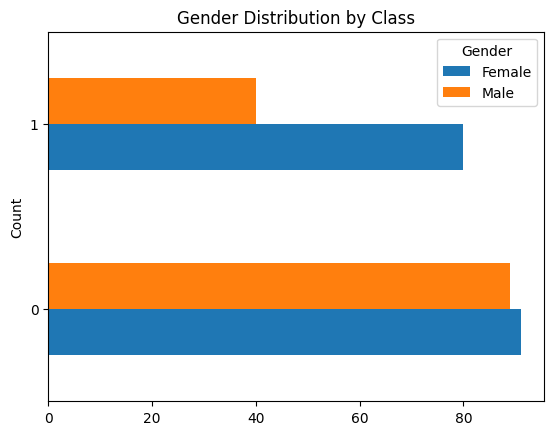

In [7]:
import matplotlib.pyplot as plt

#plot bar chart to visualise gender distribution
gender_counts = merged.groupby(["Label", "Gender"]).size().unstack()
gender_counts.plot(kind="barh")

plt.title("Gender Distribution by Class")
plt.ylabel("Count")
plt.show()

####Analysis
From this bar chart we can see that for healthy subjects, there is an approximately equal number of both male and female around 90. However there is a higher count of female subjects with alzheimers of close to 80. This is almost double the amount of males that have alzheimers (around 40) which suggests that women may be twice as succesptible towards the disease and therefore gender is a feature that could help with more accurate prediction and should be included in our model.

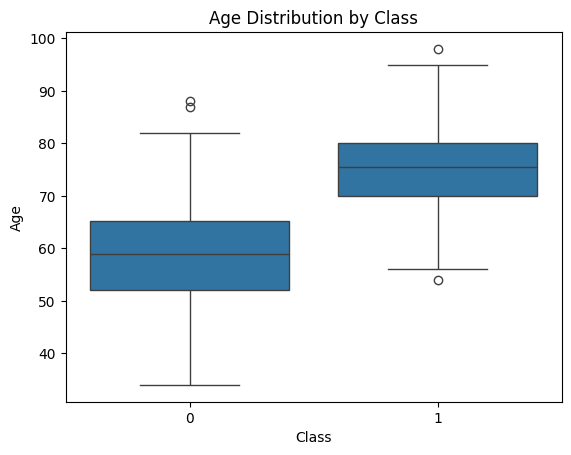

In [8]:
import seaborn as sns

plt.figure()
#plot boxplot to visualise age distribution
sns.boxplot(x="Label", y="Age", data=merged)
plt.title("Age Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Age")
plt.show()

####Analysis
In the boxplot we can firstly observe that the median age for a healthy subject is slightly less than 60 wheras a subject with alzheimers is around 15 years older at 75. Looking at the quartiles, we can also see that alzheimers subjects are older than healthy patients with no overlap.
The minimum and maximum values for alzheimers are also focussed higher (55 and 95) compared to those of healthy subjects that are more spred (30 to 82). This shows less young subjects had alzheimers. Overall, age is also an important factor with this plot suggesting that higher ages will be more likely to have/develop alzheimers.

####Target and feature definition

In [9]:
#define target
y = merged["Label"]

#define features
X = merged.drop(columns=["Label", "Subject_ID"])

####Explanation and analysis

y = output to predict

X = input features

Subject_ID is dropped as it is not meaningful in the context of the actual biology and does not effect predictions.


####Train-test split

In [10]:
from sklearn.model_selection import train_test_split

#split into training and testing sets, ensuring reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

####Results

The dataset was split into a training set (80% = 240 subjects) and testing set (20% = 60 subjects). Stratified sampling is used to preserve class distribution due to slight class imbalance, ensuring that both subsets keep their proportions representatively .

Splitting occurs based on categorical and numerical columns. Cateforical columns must go through one hot encoding to ensure binary values for a model to use and understand.

- age = numerical
- genes = numerical
- gender = categorical
- center = catergorical


##Feature engineering and selection

#### Encoding variables

In [11]:
#one-hot encoding ofcategorical variables
X_train_encoded = pd.get_dummies(X_train, columns=["Gender", "Center"],drop_first=True)

In [12]:
# encoding test
X_test_encoded = pd.get_dummies(X_test, columns=["Gender", "Center"], drop_first=True)

In [13]:
#realign columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

####Explanation and analysis

Encoding is done after data is split to prevent data leakage. One hot encoding ensures that the category information is turned into binary values to create a model.

For example - Gender information would be split into Gender_Male 0 or 1 (if drop first wasnt used then there would be a female version too)
Center1 0 or 1 Center2 0 or 1 and then a third center would not be needed if a model has both of these to distinguish by.

I also decided to keep lab center information to ensure batch effects on features are controlled.

The columns are also reindexed to ensure there is no misalignment.

####Imputing missing values

In [14]:
# compute median on training set to prevent data leakage
train_medians = X_train_encoded.median()

In [15]:
#impute missing values in sets with median
X_train_imputed = X_train_encoded.fillna(train_medians)
X_test_imputed   = X_test_encoded.fillna(train_medians)

####Explanation and analysis / results
Median imputing was chosen as there was a very small proportion of missing values that were evenly distributed. The imputation is not changed by extreme values and outliers that are common in biological data so provides a good representation.
Imputing also was applied after splitting to ensure data leakage doesnt occur. All missing values now have been filled.


####Scaling the sets

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#scale features in datasets
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled   = scaler.transform(X_test_imputed)

####Results
Training data was scaled using .fit_transform but testing data was using .transform to compute mean and standard deviations only on the individual sets - so the values arent recalculated on the testing set. This prevents data leakage again.

##Model training

####Model creation

In [17]:
from sklearn.linear_model import LogisticRegression

#create baseline classifier
bl_model = LogisticRegression(random_state=42, max_iter=1000)

#train baseline classifier on trained scaled dataset
bl_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [18]:
from sklearn.metrics import f1_score

#apply model to test dataset
y_pred = bl_model.predict(X_test_scaled)

#calculate F1 score
print("Baseline F1 score:", f1_score(y_test, y_pred))

Baseline F1 score: 0.6190476190476191


####Hyperparameter tuning

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

#baseline model defined
LR = LogisticRegression(random_state=42, max_iter=1000)

#define hyperparameter grid
hyperparameter_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100], "solver": ["liblinear", "lbfgs"]}

#run gridsearch cross validation
grid = GridSearchCV(estimator=LR, param_grid=hyperparameter_grid, cv=5, scoring="f1")

#train all models on training data
grid.fit(X_train_scaled, y_train)


#view best results
print("Best hyperparameters:", grid.best_params_)
print("Best GridSearchCV F1 score training:", grid.best_score_)

#run on test set to evaluate
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print("GridSearchCV F1 score testing: ", f1_score(y_test, y_pred))

Best hyperparameters: {'C': 0.001, 'solver': 'liblinear'}
Best GridSearchCV F1 score training: 0.6812498994869814
GridSearchCV F1 score testing:  0.6530612244897959


####Analysis and exploration
A binary classification model had to be chosen and so a support vector machine model and a logistic regression model were tested. The SVM had a slightly lower F1 score 0f 0.62 even with hypertuned parameters and so was removed from the notebook to prevent unecessary confusion and so logistic regression was chosen as a final model with an F1 score of 0.68.

After tuning hyperparameters with gridseachcv the best parameters included C = 0.001 which shows strong regularisation is needed. After running on the test set an F1 of 0.65 is obtained. This is lower than the CV f1 of 0.68 as there are 5 splits and more data for CV. This is a small different of 0.03 which seems reasonable and doesnt indicate high overfitting.

#### Model Evaluation

In [20]:
#import built in evaluation metric libraries
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

#calculate and print metrics for evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))



Accuracy: 0.7166666666666667
Precision: 0.64
Recall: 0.6666666666666666
F1 Score: 0.6530612244897959


In [21]:
#confusion matrics
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[27  9]
 [ 8 16]]


####Results and analysis
- accuracy = 71.7% :
Out of the 60 subjects in the test sample: 71% were predicted correctly

- precision = 64% :
 36% of predictions of alzheimers are false positive cases

- recall = 66.7% :
Out of all the subjects that had alzheimers, 65% were predicted correctly so almost a third of cases are missed

These metrics are ok but not the best. These along with the confusion metrics show that most positive cases are identified correctly. Unfortunately around 1/3 of true cases are missed so this model should still be optimised before real use.




##Retraining the model on the entire dataset
- the same procedure for creating a model as above was applied across the entire complete dataset for the actual predictions. This provides a larger amount of data for training on the same best model as earlier.

In [22]:
best_params = grid.best_params_

#use best hyperparameters
final_model = LogisticRegression( random_state=42, max_iter=1000, C=best_params["C"], solver=best_params["solver"])

y_complete = merged["Label"]
X_complete = merged.drop(columns=["Label", "Subject_ID"])

In [23]:
X_complete_encoded = pd.get_dummies(X_complete, columns=["Gender", "Center"], drop_first=True)


In [24]:
complete_medians = X_complete_encoded.median()
X_complete_imputed = X_complete_encoded.fillna(complete_medians)

In [25]:

scaler_final = StandardScaler()
X_complete_scaled = scaler_final.fit_transform(X_complete_imputed)

final_model.fit(X_complete_scaled, y_complete)


LogisticRegression(C=0.001, max_iter=1000, random_state=42, solver='liblinear')

##Prediction pipeline

####Loading data, copying subject ids

In [26]:
metadata_unseen_df = pd.read_csv("metadata_test.csv")
gene_expression_unseen_df  = pd.read_csv("gene_expression_data_test.csv")

unseen = pd.merge(metadata_unseen_df, gene_expression_unseen_df, on="Subject_ID")

#list of subject ids for submission file
unseen_subject_ids = unseen["Subject_ID"].copy()

X_unseen = unseen.drop(columns=["Subject_ID"], errors="ignore")


####Preprocessing: endoding, imputing, scaling

In [27]:
X_unseen_encoded = pd.get_dummies(X_unseen, columns=["Gender", "Center"], drop_first=True)

X_unseen_encoded = X_unseen_encoded.reindex(columns=X_complete_encoded.columns, fill_value=0)

X_unseen_imputed = X_unseen_encoded.fillna(complete_medians)
X_unseen_scaled = scaler_final.transform(X_unseen_imputed)


####Model predictions

In [28]:
unseen_pred = final_model.predict(X_unseen_scaled)

####Loading labels and subject ids into file

In [29]:
#create dataframe of subject_ids and predictions
submission = pd.DataFrame({"Subject_ID": unseen_subject_ids, "Label": unseen_pred})

#convert to a csv file
submission.to_csv("submission.csv", index=False)

#ensure 100 rows (subjects) and 2 columns (subject id and label)
print("Saved submission.csv:", submission.shape)
submission.head()

#distribution of labels
print(len(submission))
print(submission["Label"].value_counts())

Saved submission.csv: (100, 2)
100
Label
0    55
1    45
Name: count, dtype: int64
